# Implémentation d'Adam *from scratch* en Python

**Sommaire**
1. Rappels : SGD et ses limites
2. Les deux briques d'Adam : Momentum et RMSProp
3. Implémentation complète d'Adam
4. Visualisation étape par étape (bias correction)
5. Expériences comparatives sur fonctions convexes
6. Ablation study sur les hyperparamètres


## 0. Imports et données

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from copy import deepcopy

# Reproductibilité
np.random.seed(42)

# ── Données synthétiques ────────────────────────────────────────────────────
# On modélise : prix = 2000 * surface + 50000 + bruit gaussien
# C'est un problème de régression linéaire dont la fonction de perte
# (MSE) est strictement convexe — cas idéal pour valider nos optimiseurs.

n = 200
surfaces = np.random.uniform(30, 150, n)
prix     = 2000 * surfaces + 50000 + np.random.normal(0, 8000, n)

# Normalisation : indispensable pour que les gradients aient des ordres
# de grandeur comparables entre les deux paramètres (a et b).
surfaces_norm = (surfaces - surfaces.mean()) / surfaces.std()
prix_norm     = (prix     - prix.mean())     / prix.std()

print(f"Jeu de données : {n} exemples")
print(f"Surface  — moyenne : {surfaces.mean():.1f} m², écart-type : {surfaces.std():.1f}")
print(f"Prix     — moyenne : {prix.mean():.0f} €,  écart-type : {prix.std():.0f}")


Jeu de données : 200 exemples
Surface  — moyenne : 88.1 m², écart-type : 35.3
Prix     — moyenne : 226701 €,  écart-type : 70836


## 1. Fonctions de perte et gradients

Le modèle est une régression linéaire :

$$\hat{y}_i = a \cdot x_i + b$$

La fonction de perte (Mean Squared Error) sur l'exemple $i$ est :

$$f_i(\theta) = (\hat{y}_i - y_i)^2 = (a x_i + b - y_i)^2$$

Son gradient par rapport aux paramètres $\theta = (a, b)$ est :

$$\nabla f_i(\theta) = \begin{pmatrix} 2(ax_i + b - y_i) \cdot x_i \\ 2(ax_i + b - y_i) \end{pmatrix}$$

La perte totale (sur tous les exemples) est la moyenne des pertes individuelles :

$$F(\theta) = \frac{1}{n} \sum_{i=1}^n f_i(\theta)$$


In [2]:
def grad_fi(theta, i, X, y):
    """Gradient de la perte sur l'exemple i."""
    a, b  = theta
    err   = a * X[i] + b - y[i]
    return np.array([2 * err * X[i], 2 * err])

def perte_totale(theta, X, y):
    """MSE sur l'ensemble du jeu de données."""
    preds = theta[0] * X + theta[1]
    return np.mean((preds - y) ** 2)

def grad_total(theta, X, y):
    """Gradient moyen sur tous les exemples (gradient complet)."""
    return np.mean(
        [grad_fi(theta, i, X, y) for i in range(len(X))], axis=0
    )

# Test rapide
theta0 = np.array([0.0, 0.0])
print(f"Perte initiale       : {perte_totale(theta0, surfaces_norm, prix_norm):.4f}")
print(f"Gradient initial ∇F  : {grad_total(theta0, surfaces_norm, prix_norm)}")


Perte initiale       : 1.0000
Gradient initial ∇F  : [-1.98805366e+00  7.48290319e-16]


## 2. SGD mini-batch: rappel et limites

Avant d'implémenter Adam, on rappelle SGD mini-batch qui servira de **baseline**.
À chaque itération $k$, SGD tire un batch $\mathcal{B}$ de taille $b$ et effectue :

$$\theta^{(k+1)} = \theta^{(k)} - \alpha \cdot \frac{1}{b} \sum_{i \in \mathcal{B}} \nabla f_i(\theta^{(k)})$$

**Limite principale :** le même taux d'apprentissage $\alpha$ s'applique
à *tous* les paramètres, indépendamment de leur comportement individuel.


In [3]:
def sgd_minibatch(theta0, X, y, alpha=0.01, b=32, n_epoques=100):
    """
    SGD mini-batch.

    Paramètres
    ----------
    theta0    : point de départ (array de taille p)
    X, y      : données
    alpha     : taux d'apprentissage (fixe)
    b         : taille du batch
    n_epoques : nombre de passages sur les données
    """
    theta    = theta0.copy()
    n        = len(X)
    indices  = list(range(n))
    hist     = [perte_totale(theta, X, y)]

    for _ in range(n_epoques):
        np.random.shuffle(indices)
        for debut in range(0, n, b):
            B = indices[debut:debut + b]
            g = np.mean([grad_fi(theta, i, X, y) for i in B], axis=0)
            theta = theta - alpha * g
        hist.append(perte_totale(theta, X, y))

    return theta, np.array(hist)

theta_sgd, hist_sgd = sgd_minibatch(
    theta0, surfaces_norm, prix_norm, alpha=0.01, b=32, n_epoques=100
)
print(f"SGD  — θ final : a={theta_sgd[0]:.4f}, b={theta_sgd[1]:.4f}")
print(f"SGD  — perte finale : {hist_sgd[-1]:.6f}")


SGD  — θ final : a=0.9932, b=0.0014
SGD  — perte finale : 0.011913


## 3. Adam: implémentation complète

### 3.1 Algorithme

Adam (Kingma & Ba, 2014) maintient pour chaque paramètre deux quantités :

- **$m_t$** — premier moment : moyenne exponentielle des gradients passés
- **$v_t$** — second moment : moyenne exponentielle des gradients *au carré*

À chaque itération $t$, les cinq étapes sont :

**Étape 1** — Calculer le gradient sur le batch courant :
$$g_t = \frac{1}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \nabla f_i(\theta^{(t)})$$

**Étape 2** — Mettre à jour le premier moment (moyenne lissée des gradients) :
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$

**Étape 3** — Mettre à jour le second moment (variance lissée des gradients) :
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

**Étape 4** — Appliquer la correction du biais (*bias correction*) :
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Étape 5** — Mettre à jour les paramètres :
$$\theta^{(t+1)} = \theta^{(t)} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}$$

### 3.2 Rôle de la bias correction

$m_0 = v_0 = 0$, donc aux premières itérations $m_t$ et $v_t$ sont
fortement tirés vers zéro. Sans correction, le premier pas serait
artificiellement petit. La correction $(1 - \beta^t)$ compense cet effet
et croît de 0 vers 1 à mesure que $t$ augmente.


In [4]:
def adam(theta0, X, y,
         alpha=0.001, beta1=0.9, beta2=0.999, eps=1e-8,
         b=32, n_epoques=100):
    """
    Adam optimizer — implémentation from scratch.

    Paramètres
    ----------
    theta0            : point de départ
    X, y              : données
    alpha             : taux d'apprentissage global       (défaut 0.001)
    beta1             : taux de décroissance du 1er moment (défaut 0.9)
    beta2             : taux de décroissance du 2e moment  (défaut 0.999)
    eps               : stabilisateur numérique            (défaut 1e-8)
    b                 : taille du mini-batch
    n_epoques         : nombre d'époques

    Retourne
    --------
    theta  : paramètres optimisés
    hist   : historique de la perte totale (une valeur par époque)
    """
    theta   = theta0.copy()
    n       = len(X)
    indices = list(range(n))

    # Initialisation des moments à zéro
    m = np.zeros_like(theta)   # 1er moment
    v = np.zeros_like(theta)   # 2e moment
    t = 0                      # compteur global d'itérations

    hist = [perte_totale(theta, X, y)]

    for _ in range(n_epoques):
        np.random.shuffle(indices)

        for debut in range(0, n, b):
            B  = indices[debut:debut + b]
            t += 1

            # Étape 1 : gradient sur le batch
            g = np.mean([grad_fi(theta, i, X, y) for i in B], axis=0)

            # Étape 2 : mise à jour du 1er moment
            m = beta1 * m + (1 - beta1) * g

            # Étape 3 : mise à jour du 2e moment
            v = beta2 * v + (1 - beta2) * g ** 2

            # Étape 4 : bias correction
            m_hat = m / (1 - beta1 ** t)
            v_hat = v / (1 - beta2 ** t)

            # Étape 5 : mise à jour des paramètres
            theta = theta - alpha * m_hat / (np.sqrt(v_hat) + eps)

        hist.append(perte_totale(theta, X, y))

    return theta, np.array(hist)

theta_adam, hist_adam = adam(
    theta0, surfaces_norm, prix_norm, alpha=0.01, n_epoques=100
)
print(f"Adam — θ final : a={theta_adam[0]:.4f}, b={theta_adam[1]:.4f}")
print(f"Adam — perte finale : {hist_adam[-1]:.6f}")


Adam — θ final : a=0.9946, b=-0.0015
Adam — perte finale : 0.011913


## 4. Visualisation de la bias correction

On trace $1 - \beta_1^t$ et $1 - \beta_2^t$ en fonction de $t$ pour montrer
à quel point la correction est forte aux premières itérations.


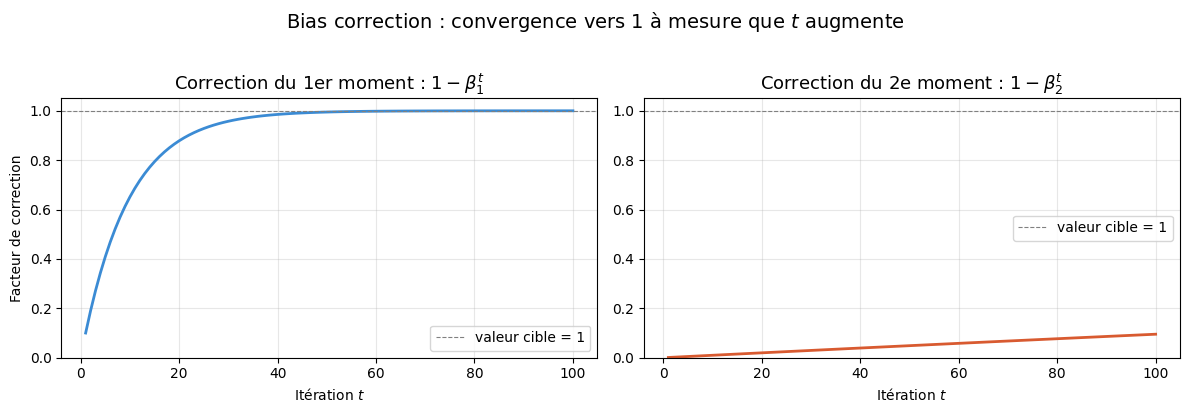

À t=1  : correction β₁ = 0.100, correction β₂ = 0.0010
À t=10 : correction β₁ = 0.651, correction β₂ = 0.0100
À t=50 : correction β₁ = 0.995, correction β₂ = 0.0488


In [5]:
beta1, beta2 = 0.9, 0.999
T = np.arange(1, 101)

corr1 = 1 - beta1 ** T   # facteur de correction du 1er moment
corr2 = 1 - beta2 ** T   # facteur de correction du 2e moment

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(T, corr1, color='#3B8BD4', lw=2)
axes[0].axhline(1, color='gray', lw=0.8, linestyle='--', label='valeur cible = 1')
axes[0].set_title(r'Correction du 1er moment : $1 - \beta_1^t$', fontsize=13)
axes[0].set_xlabel('Itération $t$')
axes[0].set_ylabel('Facteur de correction')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(T, corr2, color='#D85A30', lw=2)
axes[1].axhline(1, color='gray', lw=0.8, linestyle='--', label='valeur cible = 1')
axes[1].set_title(r'Correction du 2e moment : $1 - \beta_2^t$', fontsize=13)
axes[1].set_xlabel('Itération $t$')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Bias correction : convergence vers 1 à mesure que $t$ augmente',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('bias_correction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"À t=1  : correction β₁ = {corr1[0]:.3f}, correction β₂ = {corr2[0]:.4f}")
print(f"À t=10 : correction β₁ = {corr1[9]:.3f}, correction β₂ = {corr2[9]:.4f}")
print(f"À t=50 : correction β₁ = {corr1[49]:.3f}, correction β₂ = {corr2[49]:.4f}")


## 5. Comparaison SGD vs Adam — courbes de convergence

On compare les deux optimiseurs sur le même problème, avec le même point
de départ et le même taux d'apprentissage $\alpha = 0.01$.


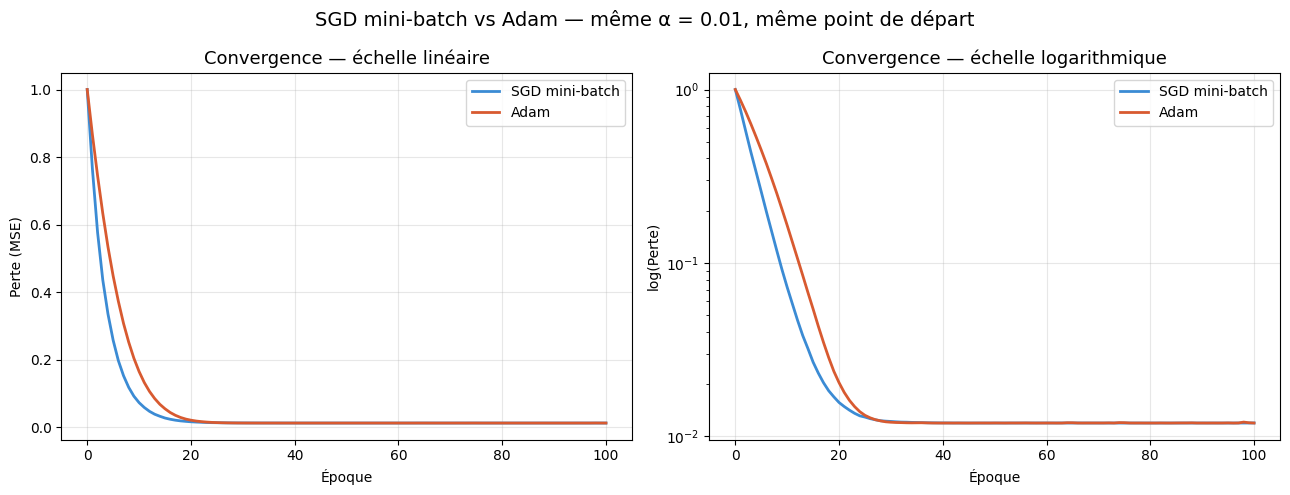

Perte finale SGD  : 0.011925
Perte finale Adam : 0.011912


In [6]:
# Relancer les deux pour s'assurer de conditions identiques
np.random.seed(42)
theta0 = np.array([0.0, 0.0])

_, hist_sgd  = sgd_minibatch(theta0, surfaces_norm, prix_norm,
                              alpha=0.01, b=32, n_epoques=100)
np.random.seed(42)
_, hist_adam = adam(theta0, surfaces_norm, prix_norm,
                    alpha=0.01, b=32, n_epoques=100)

epoques = np.arange(len(hist_sgd))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Échelle linéaire
axes[0].plot(epoques, hist_sgd,  label='SGD mini-batch', color='#3B8BD4', lw=2)
axes[0].plot(epoques, hist_adam, label='Adam',           color='#D85A30', lw=2)
axes[0].set_title('Convergence — échelle linéaire', fontsize=13)
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Perte (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Échelle logarithmique (révèle mieux les différences de vitesse)
axes[1].semilogy(epoques, hist_sgd,  label='SGD mini-batch', color='#3B8BD4', lw=2)
axes[1].semilogy(epoques, hist_adam, label='Adam',           color='#D85A30', lw=2)
axes[1].set_title('Convergence — échelle logarithmique', fontsize=13)
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('log(Perte)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('SGD mini-batch vs Adam — même α = 0.01, même point de départ',
             fontsize=14)
plt.tight_layout()
plt.savefig('convergence_sgd_adam.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Perte finale SGD  : {hist_sgd[-1]:.6f}")
print(f"Perte finale Adam : {hist_adam[-1]:.6f}")


## 6. Ablation study

On étudie l'effet de chaque hyperparamètre individuellement en ne faisant
varier qu'un seul à la fois.

### 6.1 Sensibilité au taux d'apprentissage α


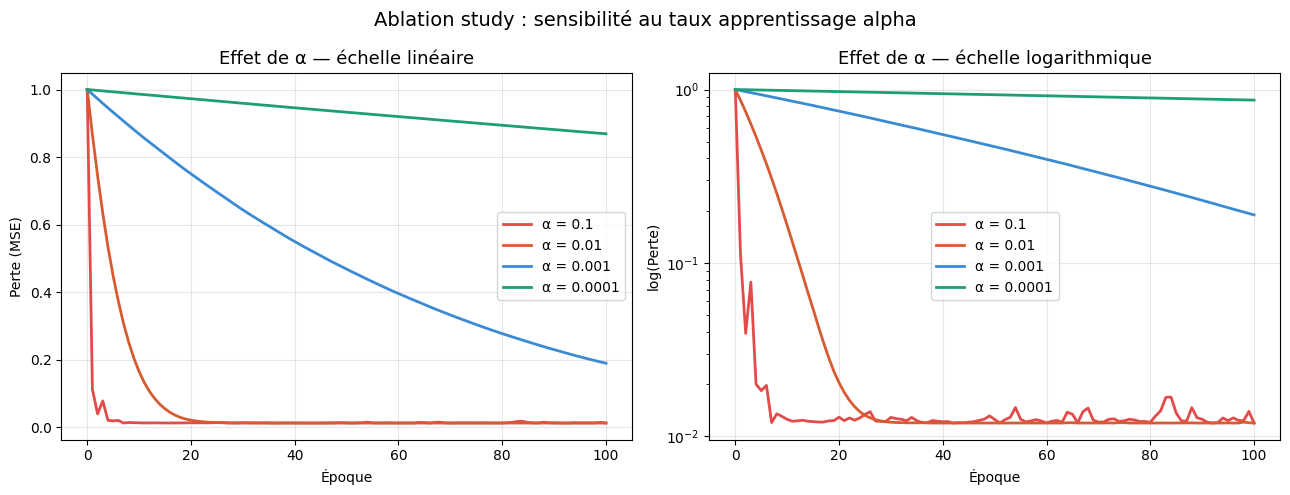

In [7]:
alphas = [0.1, 0.01, 0.001, 0.0001]
couleurs = ['#E24B4A', '#D85A30', '#3B8BD4', '#1D9E75']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for alpha, couleur in zip(alphas, couleurs):
    np.random.seed(42)
    _, hist = adam(theta0, surfaces_norm, prix_norm,
                   alpha=alpha, n_epoques=100)
    label = f'α = {alpha}'
    axes[0].plot(hist,         label=label, color=couleur, lw=2)
    axes[1].semilogy(hist,     label=label, color=couleur, lw=2)

for ax in axes:
    ax.set_xlabel('Époque')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_title('Effet de α — échelle linéaire', fontsize=13)
axes[0].set_ylabel('Perte (MSE)')
axes[1].set_title('Effet de α — échelle logarithmique', fontsize=13)
axes[1].set_ylabel('log(Perte)')

plt.suptitle("Ablation study : sensibilité au taux apprentissage alpha", fontsize=14)
plt.tight_layout()
plt.savefig('ablation_alpha.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Sensibilité à β₁ (premier moment)

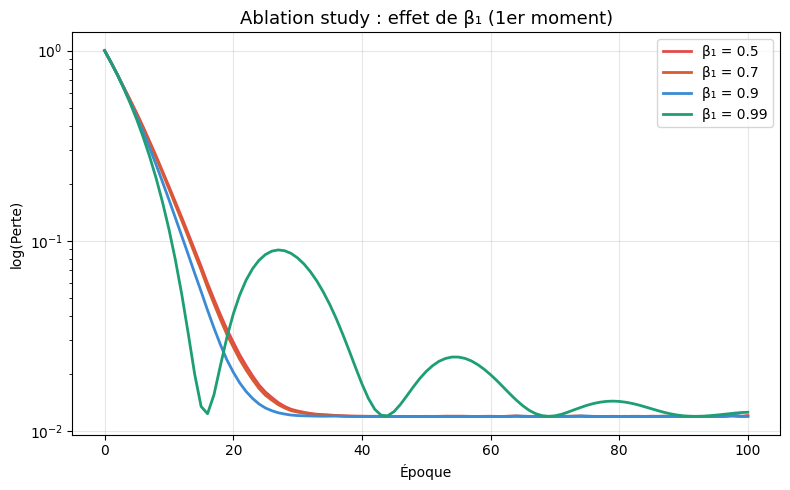

In [8]:
beta1_vals = [0.5, 0.7, 0.9, 0.99]
couleurs   = ['#E24B4A', '#D85A30', '#3B8BD4', '#1D9E75']

fig, ax = plt.subplots(figsize=(8, 5))

for beta1, couleur in zip(beta1_vals, couleurs):
    np.random.seed(42)
    _, hist = adam(theta0, surfaces_norm, prix_norm,
                   alpha=0.01, beta1=beta1, n_epoques=100)
    ax.semilogy(hist, label=f'β₁ = {beta1}', color=couleur, lw=2)

ax.set_xlabel('Époque')
ax.set_ylabel('log(Perte)')
ax.set_title('Ablation study : effet de β₁ (1er moment)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_beta1.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Sensibilité à β₂ (second moment)

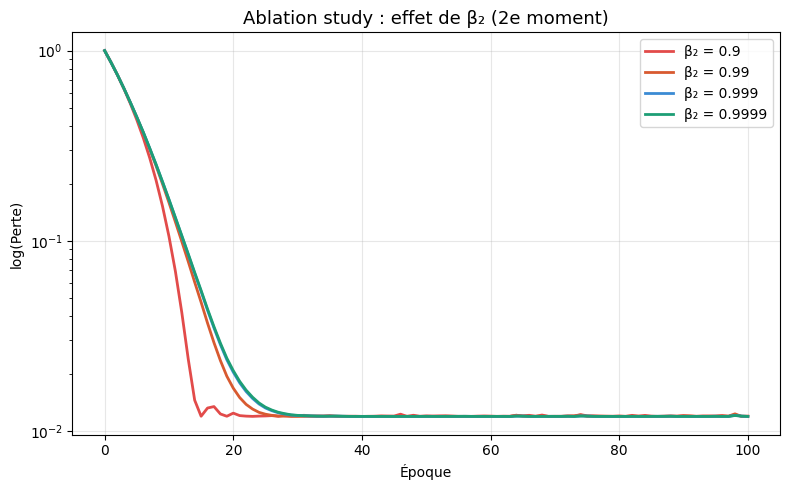

In [9]:
beta2_vals = [0.9, 0.99, 0.999, 0.9999]
couleurs   = ['#E24B4A', '#D85A30', '#3B8BD4', '#1D9E75']

fig, ax = plt.subplots(figsize=(8, 5))

for beta2, couleur in zip(beta2_vals, couleurs):
    np.random.seed(42)
    _, hist = adam(theta0, surfaces_norm, prix_norm,
                   alpha=0.01, beta2=beta2, n_epoques=100)
    ax.semilogy(hist, label=f'β₂ = {beta2}', color=couleur, lw=2)

ax.set_xlabel('Époque')
ax.set_ylabel('log(Perte)')
ax.set_title('Ablation study : effet de β₂ (2e moment)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_beta2.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Impact de la bias correction

On compare Adam avec et sans bias correction pour quantifier son apport,
particulièrement aux premières itérations.


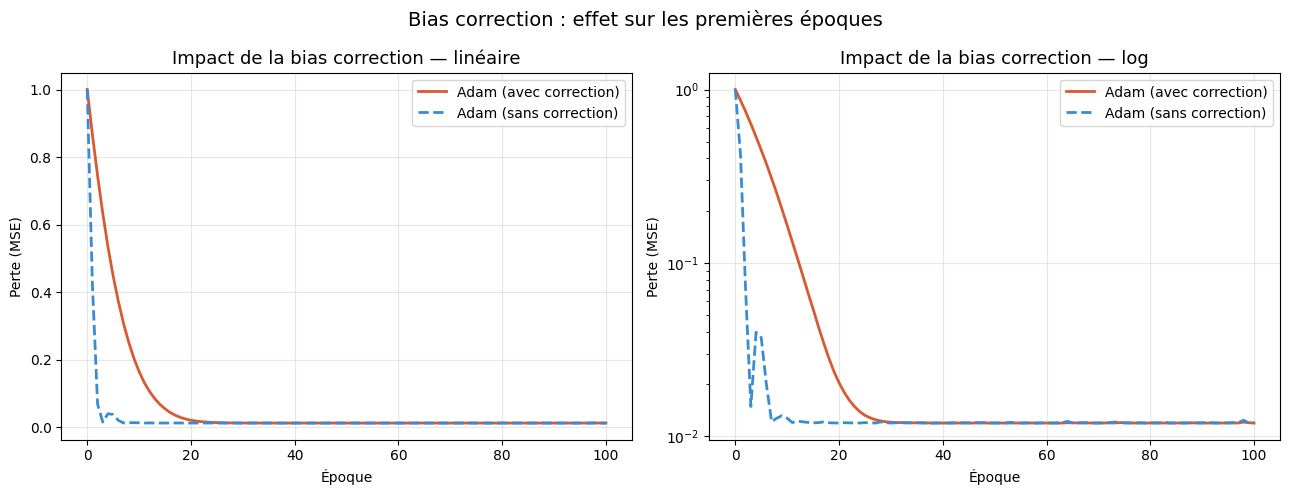

Perte finale avec correction    : 0.011912
Perte finale sans correction    : 0.011940


In [10]:
def adam_sans_correction(theta0, X, y,
                          alpha=0.001, beta1=0.9, beta2=0.999,
                          eps=1e-8, b=32, n_epoques=100):
    """Adam sans la bias correction — pour comparaison."""
    theta   = theta0.copy()
    n       = len(X)
    indices = list(range(n))
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)
    hist = [perte_totale(theta, X, y)]

    for _ in range(n_epoques):
        np.random.shuffle(indices)
        for debut in range(0, n, b):
            B = indices[debut:debut + b]
            g = np.mean([grad_fi(theta, i, X, y) for i in B], axis=0)
            m = beta1 * m + (1 - beta1) * g
            v = beta2 * v + (1 - beta2) * g ** 2
            # Pas de bias correction ici
            theta = theta - alpha * m / (np.sqrt(v) + eps)
        hist.append(perte_totale(theta, X, y))

    return theta, np.array(hist)

np.random.seed(42)
_, hist_avec    = adam(theta0, surfaces_norm, prix_norm,
                       alpha=0.01, n_epoques=100)
np.random.seed(42)
_, hist_sans    = adam_sans_correction(theta0, surfaces_norm, prix_norm,
                                       alpha=0.01, n_epoques=100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    if yscale == 'log':
        ax.semilogy(hist_avec, label='Adam (avec correction)', color='#D85A30', lw=2)
        ax.semilogy(hist_sans, label='Adam (sans correction)', color='#3B8BD4',
                    lw=2, linestyle='--')
    else:
        ax.plot(hist_avec, label='Adam (avec correction)', color='#D85A30', lw=2)
        ax.plot(hist_sans, label='Adam (sans correction)', color='#3B8BD4',
                lw=2, linestyle='--')
    ax.set_xlabel('Époque')
    ax.set_ylabel('Perte (MSE)')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_title('Impact de la bias correction — linéaire', fontsize=13)
axes[1].set_title('Impact de la bias correction — log', fontsize=13)

plt.suptitle('Bias correction : effet sur les premières époques', fontsize=14)
plt.tight_layout()
plt.savefig('bias_correction_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Perte finale avec correction    : {hist_avec[-1]:.6f}")
print(f"Perte finale sans correction    : {hist_sans[-1]:.6f}")


## 8. Tableau récapitulatif des hyperparamètres

| Hyperparamètre | Valeur par défaut | Rôle | Effet si trop grand | Effet si trop petit |
|---|---|---|---|---|
| α (learning rate) | 0.001 | Amplitude du pas | Divergence / oscillations | Convergence très lente |
| β₁ | 0.9 | Mémoire du gradient (momentum) | Inertie excessive, dépasse le minimum | Pas d'effet de lissage → comme SGD |
| β₂ | 0.999 | Mémoire de la variance | Adaptation très lente | Trop sensible aux gradients récents |
| ε | 1e-8 | Stabilité numérique | Annule l'adaptation (↗ ε = ↘ Adam → SGD) | Division par zéro possible |
| b (batch size) | 32 | Qualité du gradient estimé | Gradient plus précis, plus lent par époque | Gradient bruité, mises à jour fréquentes |

### Valeurs recommandées (Kingma & Ba, 2014)

```
α = 0.001,  β₁ = 0.9,  β₂ = 0.999,  ε = 1e-8
```

Ces valeurs sont robustes pour la grande majorité des problèmes.


## 9. Conclusion

Ce notebook a implémenté Adam depuis zéro en décomposant chacune des cinq
étapes de l'algorithme. Les points clés à retenir :

1. **Adam combine deux idées** : le momentum (lissage de la direction)
   et l'adaptation par paramètre (via le second moment).

2. **La bias correction** est essentielle aux premières itérations pour
   compenser l'initialisation à zéro des moments.

3. **Adam est plus robuste au choix de α** que SGD : un même α = 0.01
   fonctionne bien sur ce problème, alors que SGD nécessite un réglage fin.

4. **Sur les problèmes convexes simples**, la différence avec SGD est
   faible. L'avantage d'Adam se manifeste pleinement sur des architectures
   profondes avec des gradients hétérogènes entre les couches.

